In [302]:
import pandas as pd
import numpy as np

In [303]:
data = pd.read_csv('Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [304]:
X = data.iloc[:, :-1]
X.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [305]:
data = pd.get_dummies(data, columns=['Species'], dtype=float)
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
0,1,5.1,3.5,1.4,0.2,1.0,0.0,0.0
1,2,4.9,3.0,1.4,0.2,1.0,0.0,0.0
2,3,4.7,3.2,1.3,0.2,1.0,0.0,0.0
3,4,4.6,3.1,1.5,0.2,1.0,0.0,0.0
4,5,5.0,3.6,1.4,0.2,1.0,0.0,0.0


# Linear Regression

In [307]:
class LinearRegression:
    def __init__(self, lr=0.01, epochs=1000, shuffle=True, batch_size=32):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.batch_size = batch_size
        self.shuffle = shuffle

    def predict(self, X):
        y_pred = np.dot(X, self.w.T)
        return y_pred
    
    def loss_function(self, y, y_pred):
        return np.sum((y - y_pred)**2) / len(y)
    
    def grad(self, X, y):
        y_pred = self.predict(X)
        dw = -2*np.dot(X.T, (y - y_pred)) / len(y)
        return dw
    
    def batch_generator(self, X, y):
        if self.shuffle:
            idx = np.random.permutation(len(y))
            X, y = X[idx], y[idx]

        for i in range(0, len(y), self.batch_size):
            yield X[i : i + self.batch_size], y[i : i + self.batch_size]

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            for X_batch, y_batch in self.batch_generator(X, y):
                y_pred = self.predict(X_batch)
                
                loss = self.loss_function(y_batch, y_pred)
                losses.append(loss)

                dw = self.grad(X_batch, y_batch)
                self.w -= self.lr * dw

            if epoch % 100 == 0:
                print(f"epoch {epoch}, loss {loss}")

        return losses

In [308]:
data = pd.read_csv('advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [309]:
X = data.iloc[:, :-1].values
y = data['Sales'].values

In [310]:
def scaled(X):
    return (X - X.min()) / (X.max() - X.min())

In [311]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)
X_train_scaled, X_test_scaled, y_train, y_test = scaled(X_train), scaled(X_test), scaled(y_train), scaled(y_test)

In [312]:
model = LinearRegression()
losses = model.fit(X_train_scaled, y_train)

epoch 0, loss 0.3180778604807443
epoch 100, loss 0.017606338049299022
epoch 200, loss 0.016814316802251372
epoch 300, loss 0.017804577049139056
epoch 400, loss 0.009194637083706018
epoch 500, loss 0.01073338452285691
epoch 600, loss 0.010823265026479092
epoch 700, loss 0.01149992212868258
epoch 800, loss 0.012355208920581787
epoch 900, loss 0.009829869142684512


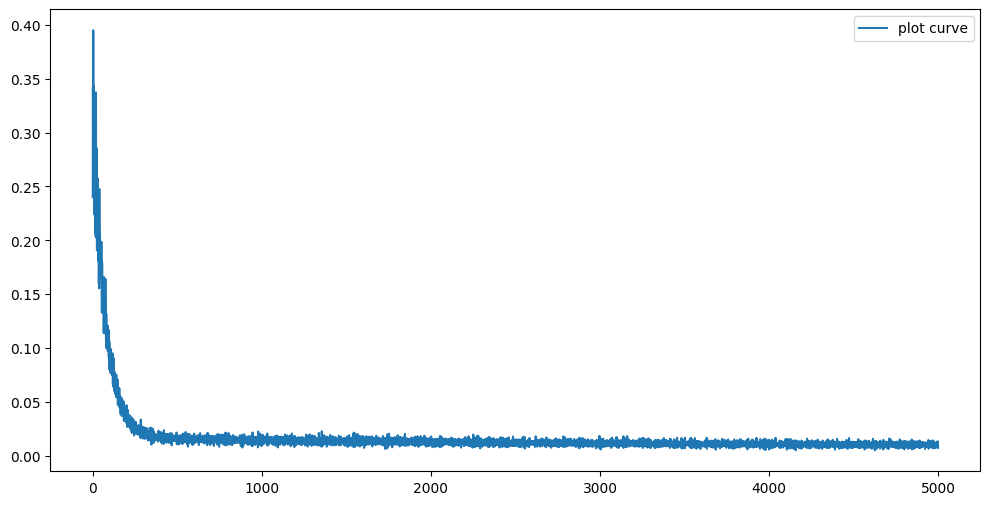

In [313]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(range(len(losses)), losses, label="plot curve")
plt.legend()
plt.show()

In [340]:
def evaluate_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mse = 1/len(X_test) * np.sum((y_test - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = 1/len(X_test) * np.sum(np.abs(y_test - y_pred))

    y_mean = np.mean(y_test)
    ssr = np.sum((y_test - y_pred)**2)
    sst = np.sum((y_test - y_mean)**2)
    r2 = 1 - ssr/sst

    return mse, rmse, mae, r2

In [ ]:
evaluate_regression(model, X_test_scaled, y_test)

(np.float64(0.008259830495557464),
 np.float64(0.0908836096089799),
 np.float64(0.0772506592938404),
 np.float64(0.8694695588232163))

## Lasso Regression

In [316]:
class LassoRegression(LinearRegression):
    def __init__(self, lr=0.01, epochs=1000, shuffle=True, batch_size=32, lambda_=0.1):
        super().__init__(lr, epochs, shuffle, batch_size)
        self.lambda_ = lambda_

    def loss_function(self, y, y_pred):
        return super().loss_function(y, y_pred) + np.sum(np.abs(self.w)) * self.lambda_
    
    def grad(self, X, y):
        grad = super().grad(X, y)
        grad += self.lambda_*np.sign(self.w)
        return grad

In [317]:
model_lasso = LassoRegression()
losses = model_lasso.fit(X_train_scaled, y_train)

epoch 0, loss 0.2918559173421762
epoch 100, loss 0.10777869218057384
epoch 200, loss 0.10922791358259597
epoch 300, loss 0.11076791782144046
epoch 400, loss 0.11075025740614207
epoch 500, loss 0.11046178136927097
epoch 600, loss 0.11059164960621509
epoch 700, loss 0.11716354409858983
epoch 800, loss 0.1084103151775742
epoch 900, loss 0.10913833113909574


In [ ]:
evaluate_regression(model_lasso, X_test_scaled, y_test)

(np.float64(0.025106814376944078),
 np.float64(0.15845129970102512),
 np.float64(0.12740953125915708),
 np.float64(0.6032359793667965))

## Ridge Regression

In [319]:
class RidgeRegression(LinearRegression):
    def __init__(self, lr=0.01, epochs=1000, shuffle=True, batch_size=32, lambda_=0.1):
        super().__init__(lr, epochs, shuffle, batch_size)
        self.lambda_ = lambda_

    def loss_function(self, y, y_pred):
        return super().loss_function(y, y_pred) + np.sum(self.w ** 2)*self.lambda_
    
    def grad(self, X, y):
        grad = super().grad(X, y)
        grad += 2*self.lambda_*self.w
        return grad

In [320]:
model_ridge = RidgeRegression()
losses = model_ridge.fit(X_train_scaled, y_train)

epoch 0, loss 0.3178301622573079
epoch 100, loss 0.09281338024238901
epoch 200, loss 0.08972548725986149
epoch 300, loss 0.07641210970414411
epoch 400, loss 0.0884553793407032
epoch 500, loss 0.08506658653583488
epoch 600, loss 0.08215819881574382
epoch 700, loss 0.08883731423184657
epoch 800, loss 0.08575743650577317
epoch 900, loss 0.08030640738500915


In [ ]:
evaluate_regression(model_ridge, X_test_scaled, y_test)

(np.float64(0.02989216246902863),
 np.float64(0.17289350036663792),
 np.float64(0.1436186816594794),
 np.float64(0.5276129265716774))

# Logistic Regression

In [322]:
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def predict_proba(self, X):
        z = np.dot(X, self.w.T)
        y_pred = self.sigmoid(z)
        return y_pred

    def predict(self, X, threshold=0.5):
        y_pred = self.predict_proba(X)
        return (y_pred >= threshold).astype(float)
    
    def binary_cross_entropy(self, y, y_pred):
        epsilon = 1e-9 
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = y*np.log(y_pred) + (1.0 - y)*np.log(1.0 - y_pred)
        return -np.mean(loss)
    
    def grad(self, X, y, y_pred):
        n_sample = X.shape[0]
        dw = np.dot(X.T, (y_pred - y))
        return 1/n_sample * dw

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            z = np.dot(X, self.w.T)
            y_pred = self.sigmoid(z)

            dw = self.grad(X, y, y_pred)
            self.w -= self.lr*dw

            loss = self.binary_cross_entropy(y, y_pred)
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"epoch {epoch}, loss {loss}")

        return losses

In [323]:
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [324]:
from sklearn.preprocessing import StandardScaler

X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']].values
y = data['Outcome'].values

scale = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)
X_train_scaled, X_test_scaled = scale.fit_transform(X_train), scale.fit_transform(X_test)

In [325]:
def evaluate(model, X, y):
    y_pred = model.predict(X, threshold=0.36)
    acc = np.mean(y == y_pred)

    tp = np.sum((y == 1) & (y_pred == 1))
    fp = np.sum((y == 0) & (y_pred == 1))
    fn = np.sum((y == 0) & (y_pred == 0))

    precision = tp / (tp + fp)
    recall = tp / (tp + fn) 
    f1 = 2*(precision * recall) / (precision + recall)

    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

In [326]:
model = LogisticRegression()
losses = model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled, threshold=0.36)
evaluate(model, X_test_scaled, y_test)

epoch 0, loss 0.6931471805599453
epoch 100, loss 0.6190731699535285
epoch 200, loss 0.5845686763763025
epoch 300, loss 0.5660944765019623
epoch 400, loss 0.5550405958175486
epoch 500, loss 0.5478688009892493
epoch 600, loss 0.5429338874535904
epoch 700, loss 0.5393878311062361
epoch 800, loss 0.5367555173344487
epoch 900, loss 0.534752165918062
Accuracy: 64.29%
Precision: 0.48
Recall: 0.48
F1 Score: 0.48


# Softmax Regression

In [327]:
def onehot_encoding(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

In [328]:
class SoftmaxRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None

    def softmax(self, z):
        exp_z = np.exp(z)
        sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)

        return exp_z/sum_exp_z
    
    def cross_entropy(self, y, y_pred):
        loss = -np.sum(y*np.log(y_pred)) / y.shape[0]
        return loss

    def predict(self, X):
        z = np.dot(X, self.w)
        y_pred = self.softmax(z)
        return np.argmax(y_pred, axis=1)
    
    def predict_class(self, X):
        z = self.predict(X)
        return np.argmax(z, axis=1)

    def fit(self, X, y):
        n_sample, n_feature = X.shape
        n_classes = len(np.unique(y))

        y_onehot = onehot_encoding(y, n_classes)
        self.w = np.random.rand(n_feature, n_classes)

        for epoch in range(self.epochs):
            z = np.dot(X, self.w)
            y_pred = self.softmax(z)

            dw = np.dot(X.T, y_pred - y_onehot) / n_sample
            self.w -= dw*self.lr

            if epoch % 100 == 0:
                loss = self.cross_entropy(y_onehot, y_pred)
                print(f'Epoch {epoch}, Loss: {loss}')

In [329]:
def evaluate_model(y_true, y_pred, num_classes):
    accuracy = np.mean(y_true == y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    
    precisions = []
    recalls = []
    f1_scores = []

    for cls in range(num_classes):
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    macro_precision = np.mean(precisions)
    macro_recall = np.mean(recalls)
    macro_f1 = np.mean(f1_scores)

    print("Macro Averages:")
    print(f"  Precision: {macro_precision:.2f}")
    print(f"  Recall:    {macro_recall:.2f}")
    print(f"  F1 Score:  {macro_f1:.2f}")


In [330]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [331]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (60000, 784)
X_test shape : (10000, 784)


In [332]:
model = SoftmaxRegression()
model.fit(X_train, y_train)

Epoch 0, Loss: 4.506799106367243
Epoch 100, Loss: 2.7253833161511865
Epoch 200, Loss: 2.066824090400246
Epoch 300, Loss: 1.6784044659959252
Epoch 400, Loss: 1.4348934588080344
Epoch 500, Loss: 1.270066838079671
Epoch 600, Loss: 1.1512054782974719
Epoch 700, Loss: 1.061283226601788
Epoch 800, Loss: 0.9907337611181489
Epoch 900, Loss: 0.933799856734197


In [333]:
y_pred = model.predict(X_test)
evaluate_model(y_pred=y_pred, y_true=y_test, num_classes=10)

Accuracy: 73.06%

Macro Averages:
  Precision: 0.73
  Recall:    0.73
  F1 Score:  0.73


# KNN

In [334]:
class KNNRegression:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        prediction = []

        for x in X:
            distance = np.linalg.norm(self.X_train - x, axis=1)

            k_indicies = np.argpartition(distance, self.k)[:self.k]

            k_nearest_values = self.y_train[k_indicies]
            mean_val = np.mean(k_nearest_values)
            
            prediction.append(mean_val)

        return np.array(prediction)


In [335]:
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('50_Startups.csv')
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [336]:
data = pd.get_dummies(data, columns=['State'], dtype=float)

X = data[['R&D Spend', 'Administration', 'Marketing Spend', 'State_California', 'State_Florida', 'State_New York']].values
y = data['Profit'].values

In [337]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

In [338]:
model = KNNRegression(k=3)
model.fit(X, y)

In [341]:
mse, rmse, mae, r2 = evaluate_regression(model, X_test, y_test)

print(f'rmse: {rmse}')
print(f'mae: {mae}')
print(f'r2: {r2}')

rmse: 6134.294629124393
mae: 5162.589333333327
r2: 0.9616600948850523


In [356]:
class KNNClassification:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.reshape(-1).astype(int)

    def predict(self, X):
        prediction = []

        for x in X:
            distance = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

            k_indicies = np.argpartition(distance, self.k - 1)[:self.k]

            k_nearest_values = self.y_train[k_indicies]
            
            most_common = np.bincount(k_nearest_values).argmax()
            prediction.append(most_common)

        return np.array(prediction)


In [349]:
data = pd.read_csv('Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [344]:
data['Species'] = data['Species'].str.strip().str.lower()

data['Species'] = data['Species'].map({
    'iris-setosa': 0,
    'iris-versicolor': 1,
    'iris-virginica': 2
})
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [346]:
X = data[['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = data['Species'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

In [357]:
model = KNNClassification(k=5)
model.fit(X_train, y_train)

In [358]:
def accuracy_classification(model, X, y):
    y_pred = model.predict(X)
    y = y.reshape(-1)
    y_pred = y_pred.reshape(-1)
    return np.mean(y == y_pred)

acc = accuracy_classification(model, X_test, y_test)
print(acc)

1.0


# K-means

In [360]:
class KMeans:
    def __init__(self, k=None, max_iter=10):
        self.k = k
        self.max_iter = max_iter
        self.all_centroids = []
        self.all_labels = []

    def get_labels(self, dataset, centroids):
        labels = []
        for x in dataset:
            distance = np.sum((x - centroids)**2, axis=1)
            label = np.argmin(distance)
            labels.append(label)
        return labels

    def get_centroid(self, dataset, labels, k):
        centroids = []

        for i in np.arange(k):
            idx_i = np.where(np.array(labels)==i)[0]
            centroid_i = dataset[idx_i, :].mean(axis=0)
            centroids.append(centroid_i)

        return centroids
    
    def fit(self, dataset):
        num_feature = dataset.shape[1]
        centroids = np.random.rand(self.k, num_feature)

        self.all_centroids.append(centroids)
        self.all_labels.append(None)

        it = 0
        old_centroid = None

        while (it < self.max_iter) and (old_centroid is None or not np.allclose(old_centroid, centroids)):
            old_centroid = centroids
            it += 1

            labels = self.get_labels(dataset, centroids)
            self.all_labels.append(labels)

            centroids = self.get_centroid(dataset, labels, self.k)
            self.all_centroids.append(centroids)

        return centroids

In [362]:
from sklearn.datasets import make_blobs

dataset, _ = make_blobs(n_samples=250, cluster_std=3.0, random_state=36)

kmean = KMeans(k=2, max_iter=8)
centroids = kmean.fit(dataset)

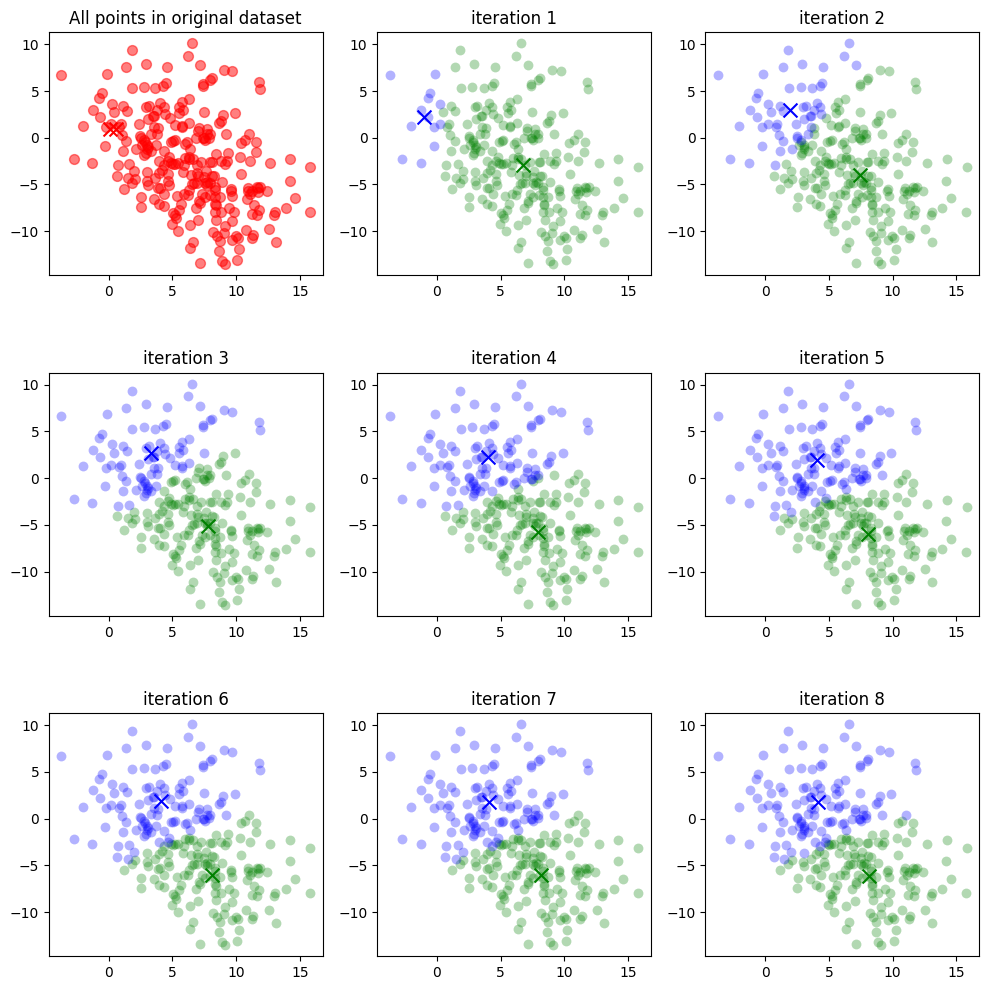

In [363]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

gs = GridSpec(nrows=3, ncols=3)
plt.figure(figsize = (12, 12))
plt.subplots_adjust(wspace=0.2,hspace=0.4)
colors = ['green', 'blue']
labels = ['cluster 1', 'cluster 2']

for i in np.arange(len(kmean.all_centroids)):
  ax = plt.subplot(gs[i])
  if i == 0:
    centroids_i = kmean.all_centroids[i]
    plt.scatter(dataset[:, 0], dataset[:, 1], s=50, alpha=0.5, color='red')
    for j in np.arange(kmean.k):
      plt.scatter(centroids_i[j, 0], centroids_i[j, 1], marker='x', s=100, color='red')
    plt.title('All points in original dataset')
  else:
    # Lấy centroids và labels tại bước thứ i
    centroids_i = np.array(kmean.all_centroids[i])
    labels_i = kmean.all_labels[i]
    # Visualize các điểm cho từng cụm
    for j in np.arange(kmean.k):
      idx_j = np.where(np.array(labels_i) == j)[0]
      plt.scatter(dataset[idx_j, 0], dataset[idx_j, 1], color=colors[j], label=labels[j], s=50, alpha=0.3, lw = 0)
      plt.scatter(centroids_i[j, 0], centroids_i[j, 1], marker='x', color=colors[j], s=100, label=labels[j])
    plt.title(r'iteration {}'.format(i))

# Decision Tree

In [ ]:
from collections import Counter

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None
        self.majority_class = None

    def fit(self, X, y):
        feature = list(np.unique(X.shape[1]))
        self.tree = self._build_tree(X, y, feature, depth=0)

    def _build_tree(self, X, y, feature, depth):
        if len(np.unique(y)) == 1:
            return y[0]
    
        if not feature or depth >= self.max_depth:
            return self._get_majorirty_class(y)
        
        _, best_idx = self._best_feature(X, y)

        tree = {best_idx: {}}
        values = np.unique(X[:, best_idx])

        for val in values:
            indx = X[:, best_idx] == val
            sub_X = X[indx]
            sub_y = y[indx]

            last_feature = [f for f in feature if f != best_idx]
            tree[best_idx][val] = self._build_tree(sub_X, sub_y, last_feature, depth + 1)
        return tree

    def _get_majorirty_class(self, y):
        return Counter(y).most_common(1)[0][0]    

    def _best_feature(self, y):
        gains = []
        for i in range(len(X[0])):
            ig = self._information_gain(X[:, i], y)
            gains.append(ig)
        
        return np.max(gains), np.argmax(gains)
    
    def _info_gain(self, X, y):
        e_p = self._entropy(y)
        values, cnts = np.unique(X, return_counts=True)

        w = 0
        for v, cnt in zip(values, cnts):
            s_v = y[X == v]
            e_sv = self._entropy(s_v)
            w += cnt/len(y) * e_sv

        ig = e_p - w
        return ig
            
    def _entropy(self, y):
        _, cnt = np.unique(y, return_counts=True)
        p = cnt / len(y)

        return -np.sum(p*np.log2(p))
    
    def _predict(self, X):
        return np.array([self._traversal(self.tree, x) for x in X])
    
    def _traversal(self, node, x):
        if not isinstance(node, dict):
            return node
        feature = self._best_feature(y)
        feature = list(node.keys())[0]
        feature_value = x[feature]

        if feature_value not in node[feature]:
            return self.majority_class
        
        return self._traverse(node[feature][feature_value], x)